# 04. Model Evaluation & Error Analysis
## AI Resume–Job Description Semantic Matching System

This notebook evaluates the fine-tuned DistilBERT transformer alongside the classical ML baselines on the held-out test split, visualizes diagnostic curves (Confusion Matrices, One-vs-Rest ROC, Precision-Recall), and inspects qualitative error cases.

In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

# Ensure root package directory is in sys.path
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.config import METRICS_DIR, FIGURES_DIR, PREDICTIONS_DIR
from src.evaluate import run_full_evaluation

%matplotlib inline
print("Evaluation environment initialized successfully.")

Evaluation environment initialized successfully.


### 1. Run Comprehensive Multi-Model Evaluation
Benchmarks TF-IDF Cosine Similarity, TF-IDF + Logistic Regression, and DistilBERT Sequence Classifier on the test split.

In [2]:
comparison_df = run_full_evaluation()
display(comparison_df)

[2026-09-06 19:15:47] [INFO] evaluate: Running full test evaluation on 150 test pairs...


[2026-09-06 19:15:47] [INFO] evaluate: Loading DistilBERT from C:\Users\hp\OneDrive\Desktop\Code\AI Resume–Job Description Semantic Matching System\models\distilbert_resume_matcher on cpu...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[2026-09-06 19:16:10] [INFO] evaluate: Total test errors: 52 / 150 (34.67%)


[2026-09-06 19:16:10] [INFO] evaluate: Saved qualitative error analysis (12 examples) to C:\Users\hp\OneDrive\Desktop\Code\AI Resume–Job Description Semantic Matching System\outputs\metrics


[2026-09-06 19:16:10] [INFO] evaluate: Saved final model comparison table to C:\Users\hp\OneDrive\Desktop\Code\AI Resume–Job Description Semantic Matching System\outputs\metrics\model_comparison.csv



               FINAL MODEL COMPARISON TABLE            
                       Model  Accuracy  Precision  Recall  Macro F1  Weighted F1
    TF-IDF Cosine Similarity    0.9647     0.9647  0.9647    0.9647       0.9647
TF-IDF + Logistic Regression    0.9949     0.9949  0.9949    0.9949       0.9949
     DistilBERT (Fine-Tuned)    0.6533     0.7942  0.6533    0.5547       0.5547



,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,TF-IDF Cosine Similarity,0.9647,0.9647,0.9647,0.9647,0.9647
1,TF-IDF + Logistic Regression,0.9949,0.9949,0.9949,0.9949,0.9949
2,DistilBERT (Fine-Tuned),0.6533,0.7942,0.6533,0.5547,0.5547


### 2. Confusion Matrices & Diagnostic Curves

DistilBERT Confusion Matrix:


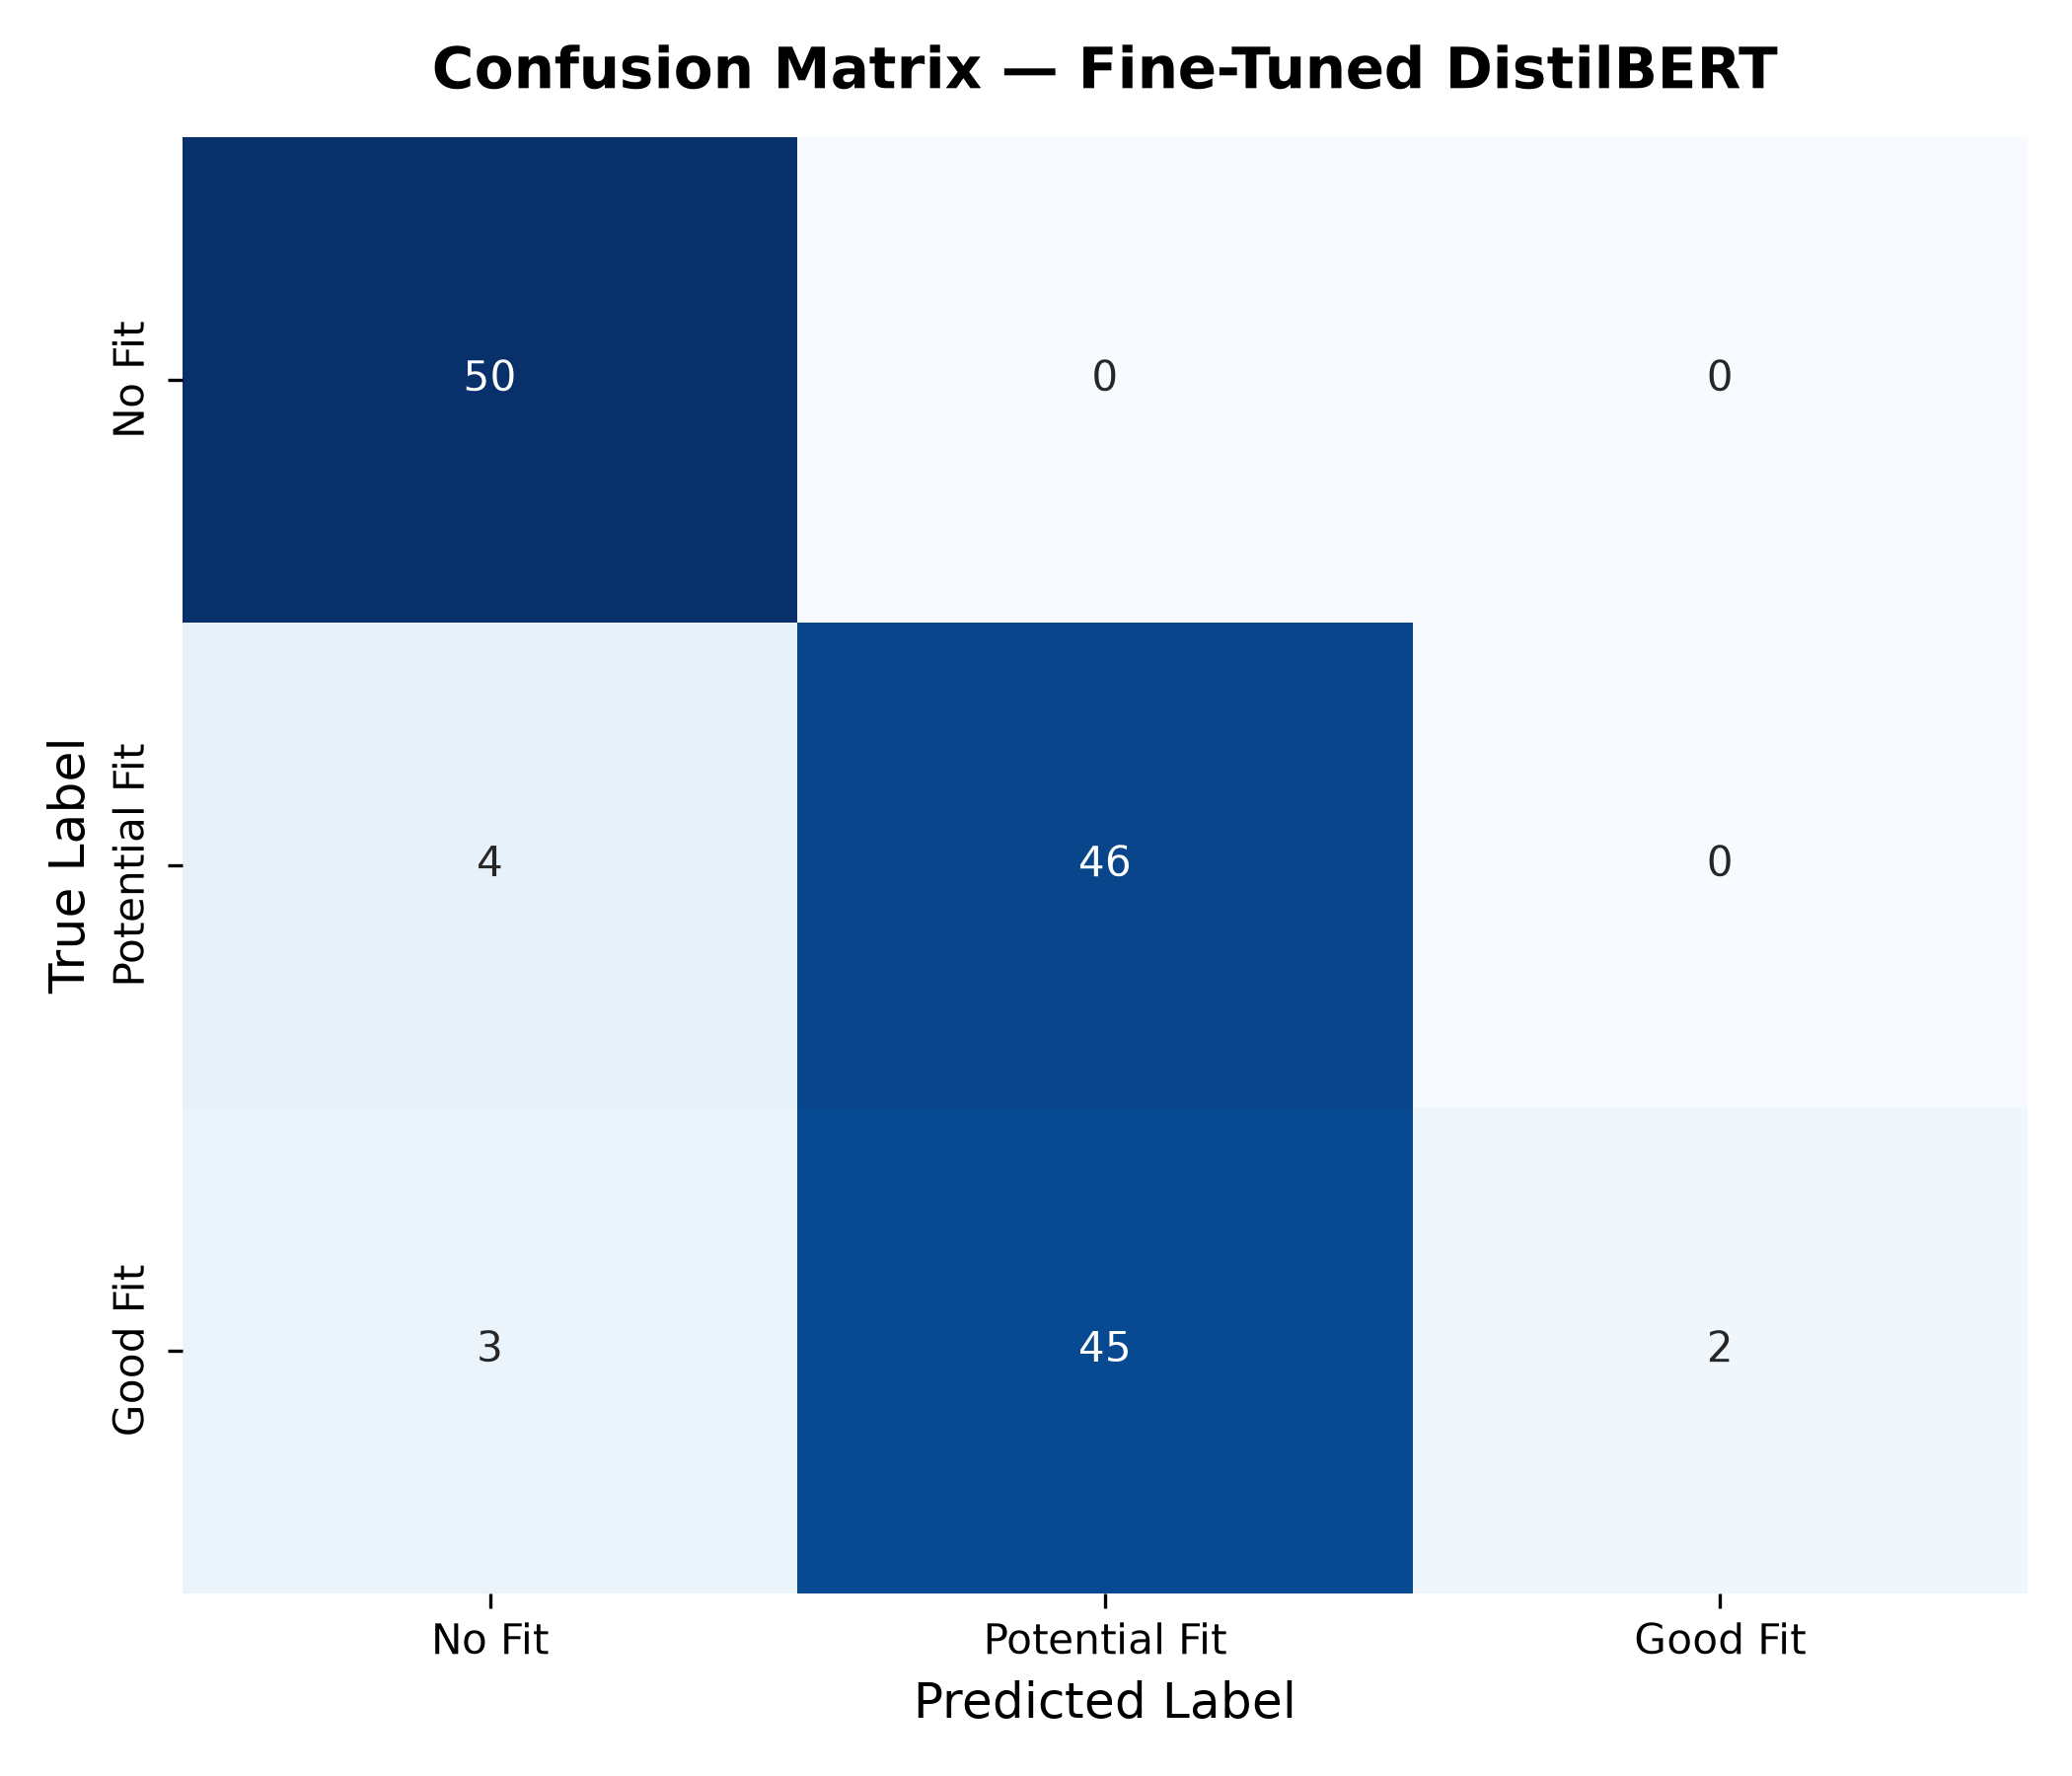

One-vs-Rest ROC Curves:


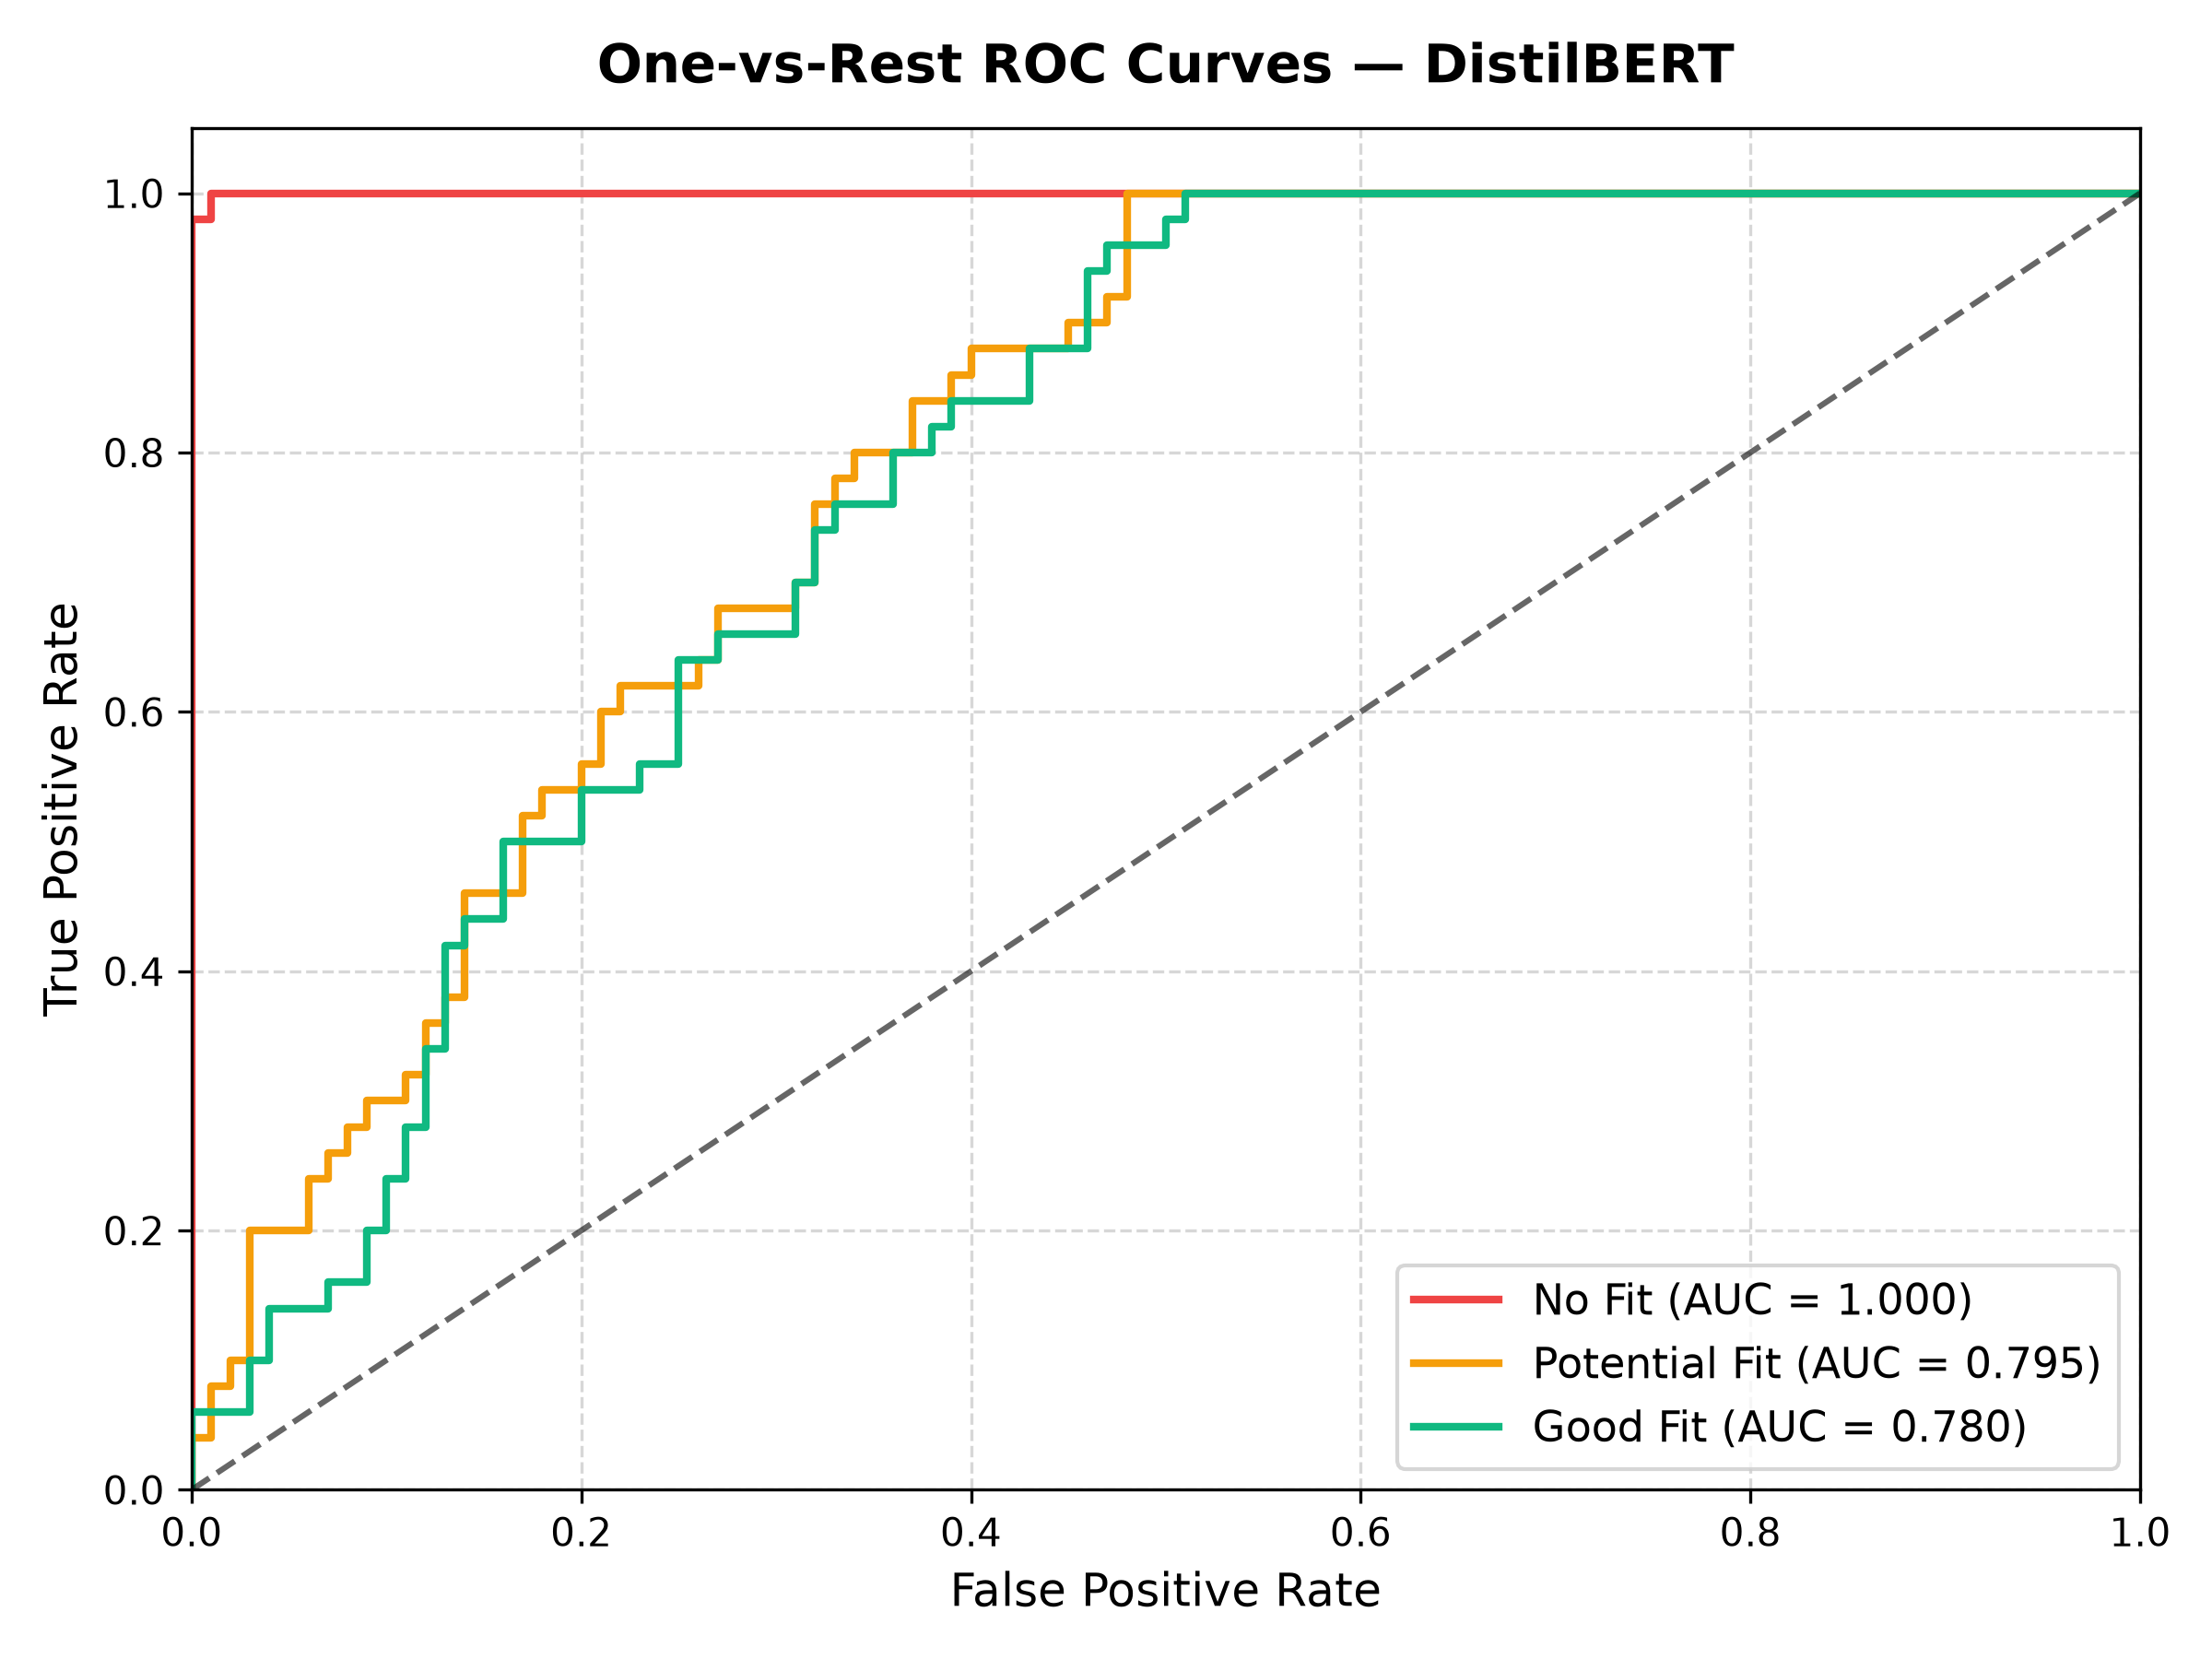

Precision-Recall Curves:


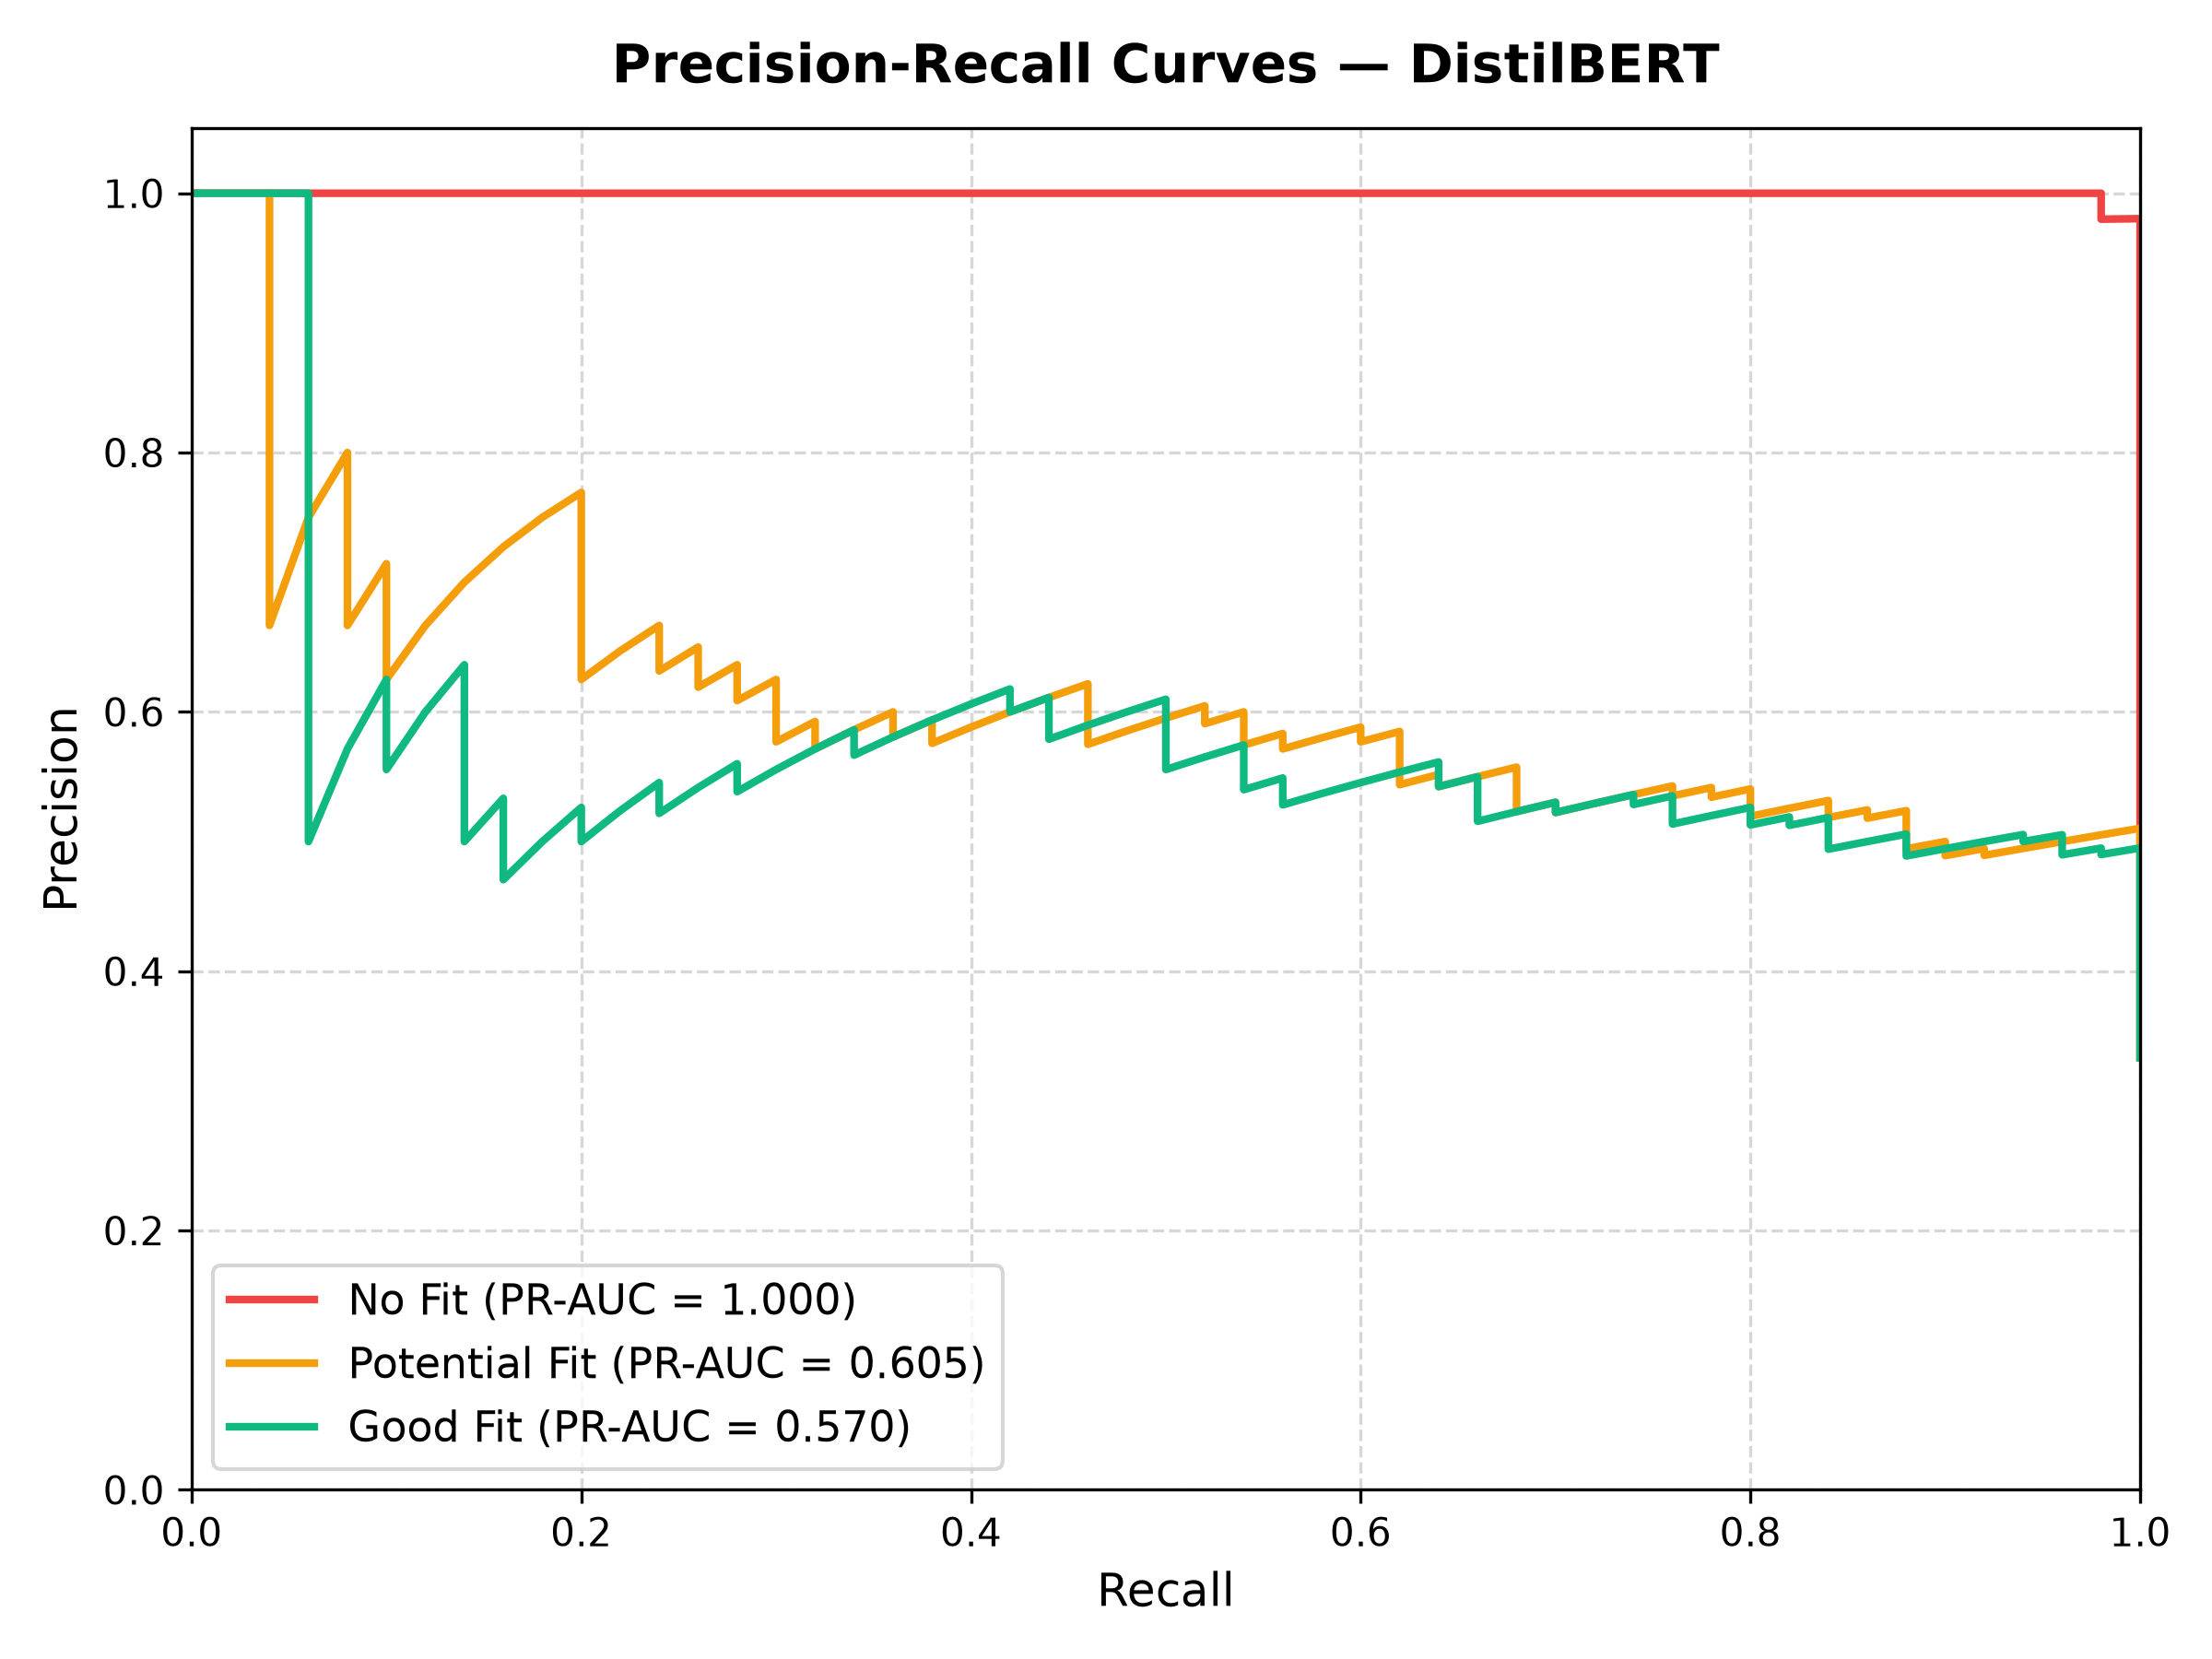

In [3]:
import sys
from pathlib import Path
from IPython.display import Image, display

root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
from src.config import FIGURES_DIR

print("DistilBERT Confusion Matrix:")
cm_path = FIGURES_DIR / "confusion_matrix_distilbert.png"
if cm_path.exists():
    display(Image(filename=str(cm_path)))

print("One-vs-Rest ROC Curves:")
roc_path = FIGURES_DIR / "roc_curve.png"
if roc_path.exists():
    display(Image(filename=str(roc_path)))

print("Precision-Recall Curves:")
pr_path = FIGURES_DIR / "pr_curve.png"
if pr_path.exists():
    display(Image(filename=str(pr_path)))

### 3. Qualitative Error Analysis
Inspect edge cases where model predictions differed from true candidate compatibility labels.

In [4]:
import json
from pathlib import Path
from src.config import METRICS_DIR

error_file = METRICS_DIR / "error_analysis.json"
if error_file.exists():
    with open(error_file, "r", encoding="utf-8") as f:
        errors = json.load(f)
    print(f"Total Analyzed Error Cases: {len(errors)}\n")
    for i, err in enumerate(errors[:3], 1):
        print(f"--- Error Case #{i} ---")
        print(f"Candidate Role: {err.get('candidate_role', 'N/A')}")
        print(f"True Label:     {err.get('true_label', 'N/A')}")
        print(f"Predicted:      {err.get('predicted_label', 'N/A')}")
        print(f"Confidence:     {err.get('predicted_confidence', 'N/A')}")
        print(f"Resume Snippet: {err.get('resume_snippet', '')[:120]}...")
        print(f"JD Snippet:     {err.get('jd_snippet', '')[:120]}...\n")
else:
    print("Run run_full_evaluation() to generate the error analysis report.")

Total Analyzed Error Cases: 12

--- Error Case #1 ---
Candidate Role: Customer Success Associate
True Label:     Good Fit
Predicted:      Potential Fit
Confidence:     N/A
Resume Snippet: Title: Senior Customer Success Associate
Professional Summary: Customer Success Associate with 7 years of experience in ...
JD Snippet:     ...

--- Error Case #2 ---
Candidate Role: Technical Support Specialist
True Label:     Good Fit
Predicted:      Potential Fit
Confidence:     N/A
Resume Snippet: Title: Senior Technical Support Specialist
Professional Summary: Technical Support Specialist with 8 years of experience...
JD Snippet:     ...

--- Error Case #3 ---
Candidate Role: Junior Accountant
True Label:     Good Fit
Predicted:      Potential Fit
Confidence:     N/A
Resume Snippet: Title: Junior Junior Accountant
Professional Summary: Junior Accountant with 2 years of experience in Cybersecurity.
Ind...
JD Snippet:     ...

